Nivell 1 - EDA estructurat i neteja bàsica

Exercici 1: Exploració inicial del dataset

Objectiu: entendre l’estructura general del dataset i detectar possibles problemes abans de començar a netejar o transformar dades.

En aquest exercici has de realitzar una exploració inicial del DataFrame per respondre, com a mínim, a les següents preguntes:

Quantes files i columnes té el dataset?

Quin tipus de dades conté cada columna?

Hi ha files duplicades?

Les dades semblen coherents a primera vista?

Detectes possibles problemes o inconsistències evidents?

Per fer-ho, hauràs de:

Analitzar les dimensions del dataset.

Mostrar una mostra representativa de files.

Revisar els tipus de variables.

Les dades semblen coherents a primera vista?.

Detectar files duplicades.

Identificar i descriure possibles problemes inicials (sense solucionar-los encara).

In [1]:
import pandas as pd

# Cargar archivo
# skiprows=3 salta las primeras tres filas porque en la cuarta fila están los encabezados.

df = pd.read_excel("sprint10_complex.xlsx", skiprows=3)

# Eliminar primera columna que solo contiene número de fila.

df = df.drop(columns=df.columns[0])


In [2]:
# Dimensiones

print("Dimensiones del Dataset:")
print()
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Dimensiones del Dataset:

Filas: 1007
Columnas: 19


In [3]:
# Filas de muestra

print("Muestra de filas (5 primeras + 5 últimas):")
print()
print(df.head())
print()
print("---")
print()
print(df.tail())

Muestra de filas (5 primeras + 5 últimas):

     Nom      Cognoms        DNI País d'origen      Ciutat  Dia de Naixement  \
0  Joana  Gil Navarro  66722344X       Espanya  Valladolid              23.0   
1   Marc       MuÃ±oz  48840994W       Espanya     Alacant               8.0   
2    Noa        Serra  14308421X       Espanya     Alacant              27.0   
3    Pol          Gil  58586340F       Espanya     Sevilla              13.0   
4  David         Vila  82070937P       Espanya      Bilbao              29.0   

   Mes de Naixement  Any de Naixement Gènere Salari mensual Fills No Fills  \
0               3.0            1958.0   Dona      1,469 â‚¬  True      NaN   
1              11.0            1960.0      H      2,718 â‚¬   NaN     True   
2               4.0            1961.0      D     1358 euros  True      NaN   
3              10.0            1985.0      H      1,478 â‚¬  True      NaN   
4              11.0            1965.0   Dona      1,284 â‚¬   NaN     True   

  Grup

In [4]:
# Tipos de datos

print("Tipos de datos por columna:")
print()
print(df.dtypes)

Tipos de datos por columna:

Nom                            object
Cognoms                        object
DNI                            object
País d'origen                  object
Ciutat                         object
Dia de Naixement              float64
Mes de Naixement              float64
Any de Naixement              float64
Gènere                         object
Salari mensual                 object
Fills                          object
No Fills                       object
Grup Professional              object
CÃ rrec                        object
Nombre_fills                  float64
Te_cotxe                       object
Km_anuals                     float64
Consum_mitja_L_100km          float64
Temperatura_mitjana_ciutat    float64
dtype: object


In [5]:
# Valores nulos/vacíos

print("Valores nulos por columna:")
print()
nulos = df.isna().sum()
nulos_pct = (df.isna().mean() * 100).round(1)
resumen_nulos = pd.DataFrame({"Nulos": nulos, "% Nulos": nulos_pct})
print(resumen_nulos[resumen_nulos["Nulos"] > 0])

Valores nulos por columna:

                            Nulos  % Nulos
Nom                             1      0.1
Cognoms                         1      0.1
DNI                             1      0.1
País d'origen                   1      0.1
Ciutat                          1      0.1
Dia de Naixement                1      0.1
Mes de Naixement                1      0.1
Any de Naixement                1      0.1
Gènere                         41      4.1
Salari mensual                  1      0.1
Fills                         588     58.4
No Fills                      422     41.9
Grup Professional               2      0.2
CÃ rrec                         2      0.2
Nombre_fills                  298     29.6
Te_cotxe                      349     34.7
Km_anuals                     692     68.7
Consum_mitja_L_100km          746     74.1
Temperatura_mitjana_ciutat     71      7.1


In [6]:
# Filas duplicadas

print()
nro_dup = df.duplicated().sum()
print(f"Filas duplicadas: {nro_dup}")


Filas duplicadas: 4


In [7]:
# DNIs duplicados

print()
print("DNIs duplicados:")
print()
dni_dup = df[df.duplicated(subset=["DNI"], keep=False)].sort_values("DNI")
print(f"Registros con DNI duplicado: {len(dni_dup)}")
print(dni_dup[["DNI", "Nom", "Cognoms", "Salari mensual", "Grup Professional"]].to_string())


DNIs duplicados:

Registros con DNI duplicado: 24
            DNI      Nom          Cognoms Salari mensual Grup Professional
604   15909601K     Laia          Navarro      1,676 â‚¬            Grup A
250   15909601K     Laia     Navarro Vila     1235 euros            Grup D
759   16618423V    Oriol           GÃ³mez      2,000 â‚¬            Grup A
758   16618423V    Oriol           GÃ³mez     1879 euros            Grup B
754   16618423V    Oriol           GÃ³mez      2.358 â‚¬               NaN
654   16618423V    Oriol           GÃ³mez     1731 euros            Grup B
692   49529438G   Alexia     PÃ©rez DÃ­az        1663â‚¬            Grup C
558   49529438G   Alexia     PÃ©rez DÃ­az      1,176 â‚¬            Grup A
757   52590001R    Oriol           Ferrer         786â‚¬            Grup A
1004  52590001R    Oriol           Ferrer         786â‚¬            Grup A
142   54013571W    Marta             Ruiz      1,276 â‚¬            Grup A
89    54013571W  Guillem      Pujol Costa      1.

In [8]:
# Valores únicos en columnas con categorías

print("Valores únicos en columnas:")
print()
for col in ["Gènere", "Grup Professional", "País d'origen"]:
    col_name = [c for c in df.columns
                if col.lower() in c.lower()]
    if col_name:
        print(f"\n{col_name[0]}: {df[col_name[0]].unique()}")

Valores únicos en columnas:


Gènere: ['Dona' 'H' 'D' 'F' 'Home' 'NC' 'M' nan 'A' '??']

Grup Professional: ['Grup B' 'Grup C' 'Grup A' 'Grup D' nan 'Z']

País d'origen: ['Espanya' 'Noruega' 'Alemanya' 'ItÃ\xa0lia' 'FranÃ§a' nan 'Narnia']


Comentarios generales:

- El dataset tiene 1007 filas y 19 columnas.

- La columna 'Salari mensual' contiene formatos heterogeneos: "1,469 €", "1358 euros", "mil vuit-cents", "n/d". Se tiene que limpiar y convertir a tipo número.

- La columna 'Gènere' tiene distintos valores para el mismo concepto: H, Home, D, Dona, F, M, NC.

- Hay 4 filas duplicadas y DNIs repetidos, por ejemplo: 55283701C está dos veces.

- Hay fechas sin ningún tipo de sentido: dia=-5, mes=99, any=3000/2026. Son registros que no es posible recuperar.

- Las columnas 'Fills' y 'No Fills' parecen redundantes.

- Hay valores de temperatura promedio negativos, por ejemplo -5 o muy altos, por ejemplo 38 y 42, se tiene que revisar.

- Hay nombres de columnas con problemas de encoding, por ejemplo 'CÃ rrec' en lugar de 'Càrrec'.

In [9]:
df.head()

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,23.0,3.0,1958.0,Dona,"1,469 â‚¬",True,NaN,Grup B,Cap de projecte,3.0,True,32108.0,25.0,10.1
1,Marc,MuÃ±oz,48840994W,Espanya,Alacant,8.0,11.0,1960.0,H,"2,718 â‚¬",NaN,True,Grup C,Senior analyst,0.0,True,19496.0,10.4,18.7
2,Noa,Serra,14308421X,Espanya,Alacant,27.0,4.0,1961.0,D,1358 euros,True,NaN,Grup A,TÃ¨cnic IT,4.0,NaN,NaN,NaN,16.7
3,Pol,Gil,58586340F,Espanya,Sevilla,13.0,10.0,1985.0,H,"1,478 â‚¬",True,NaN,Grup B,Data Analyst,2.0,False,NaN,NaN,18.3
4,David,Vila,82070937P,Espanya,Bilbao,29.0,11.0,1965.0,Dona,"1,284 â‚¬",NaN,True,Grup B,Administratiu,NaN,True,NaN,11.8,13.1


Exercici 2: Validacions bàsiques de les dades i decisions d'eliminació

Objectiu: assegurar que les dades compleixen unes condicions mínimes de qualitat i determinar quines files poden continuar sent analitzades i quines s'han de descartar.

En aquest exercici hauràs de validar aspectes clau del dataset que són crítics en qualsevol context real d'anàlisi de dades, prenent decisions justificades sobre la validesa o eliminació de registres.

Aspectes a validar:

- Existeixen identificadors únics (DNI) per a cada persona?
- Què faràs amb les files duplicades o registres repetits?
- Hi ha valors obligatoris que falten o informació incoherent?
- Detectes formats incorrectes, errors de codificació o valors impossibles?

Concretament, hauràs de:

- Corregir possibles problemes de codificació i accentuació en els noms de les columnes i en els valors de text, si escau.
- Detectar i eliminar files duplicades exactes, indicant quants registres s'han eliminat.
- Comprovar la unicitat del DNI. En cas de detectar DNIs duplicats, hauràs d'analitzar la coherència de la informació associada i descartar o anul·lar els registres que no siguin fiables, justificant clarament la decisió presa.
- Identificar els camps clau que no haurien de contenir valors nuls, detectar registres amb informació insuficient i eliminar únicament aquelles files completament buides o amb informació irrecuperable o no substituïble, explicant per què no és possible ni raonable imputar-les.

In [10]:
# Corregir encoding en nombres de columnas

# Los caracteres raros son Unicode, por ejemplo'CÃ rrec'.
# Creados cuando latin-1 es cambiado incorrectamente a utf-8.
# Ahora cambiamos nuevamente a latin-1 y los cambiamos a utf-8.
# Lo hacemos uno a uno por caracter.

def corregir_encoding(text):
    if not isinstance(text, str):
        return text
    try:
        return text.encode('latin-1').decode('utf-8')
    except (UnicodeEncodeError, UnicodeDecodeError):
        return text

# Lo aplicamos a cada columna
df.columns = [corregir_encoding(col) for col in df.columns]

print("Columnas corregidas:")
print(df.columns.tolist())


Columnas corregidas:
['Nom', 'Cognoms', 'DNI', "País d'origen", 'Ciutat', 'Dia de Naixement', 'Mes de Naixement', 'Any de Naixement', 'Gènere', 'Salari mensual', 'Fills', 'No Fills', 'Grup Professional', 'Càrrec', 'Nombre_fills', 'Te_cotxe', 'Km_anuals', 'Consum_mitja_L_100km', 'Temperatura_mitjana_ciutat']


In [11]:
# Corregir encoding en valores de texto de las columnas tipo object

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].apply(corregir_encoding)

print("Test — valores de 'Càrrec' (muestra):")
print(df['Càrrec'].value_counts().head())


Test — valores de 'Càrrec' (muestra):
Càrrec
Data Analyst             142
Tècnic IT                129
Responsable de vendes    125
Senior analyst           122
Analista                 116
Name: count, dtype: int64


In [12]:
# Eliminar filas duplicadas
# Mantenemos las primera fila y eliminamos el resto.

nro_antes = len(df)
df = df.drop_duplicates(keep='first')
nro_despues = len(df)

print(f"Filas eliminadas (duplicadas): {nro_antes - nro_despues}")
print(f"Filas restantes: {nro_despues}")

# Las filas duplicadas no tienen información adicional, con lo cual mantenerlas afecta el resultado.
# En conclusión, mantener la primera fila es seguro porque el resto que se eliminan son idénticas.

Filas eliminadas (duplicadas): 4
Filas restantes: 1003


In [13]:
# DNIs duplicados
# Si el DNI figura dos veces con la misma información, ya lo eliminamos en el paso anterior.
# Si el mismo DNI aparece con info distinta, uno de los dos debería ser incorrecto.

dni_col = 'DNI'
dni_duplicados = df[df.duplicated(subset=[dni_col], keep=False)].sort_values(dni_col)

print("Registros con DNI duplicado con datos diferentes:")
print(dni_duplicados[[dni_col, 'Nom', 'Cognoms', 'Salari mensual',
                      'Grup Professional', 'Càrrec']].to_string())

# Cuando dos filas comparten el DNI pero tienen distintos datos, ninguna de las dos son confiables, porque tendriamos que adivinar cuál es correcta.
# Mejor eliminar.

df = df[~df.duplicated(subset=[dni_col], keep=False)].copy()

print(f"Filas eliminadas por DNI duplicado con datos incoherentes: {len(dni_duplicados)}")
print(f"Filas restantes: {len(df)}")


Registros con DNI duplicado con datos diferentes:
            DNI      Nom       Cognoms Salari mensual Grup Professional                 Càrrec
250   15909601K     Laia  Navarro Vila     1235 euros            Grup D        Analista junior
604   15909601K     Laia       Navarro      1,676 â‚¬            Grup A               Analista
654   16618423V    Oriol         Gómez     1731 euros            Grup B           Data analyst
754   16618423V    Oriol         Gómez      2.358 â‚¬               NaN                    NaN
758   16618423V    Oriol         Gómez     1879 euros            Grup B           Data Analyst
759   16618423V    Oriol         Gómez      2,000 â‚¬            Grup A  Responsable de vendes
558   49529438G   Alexia    Pérez Díaz      1,176 â‚¬            Grup A           Data Analyst
692   49529438G   Alexia    Pérez Díaz        1663â‚¬            Grup C        Cap de projecte
89    54013571W  Guillem   Pujol Costa      1.574 â‚¬            Grup B           Project lead


In [14]:
# Eliminar columnas a las que les faltan campos obligatorios, por ejemplo:
# DNI, Nom, Grup Professional.

campos_obligatorios = [dni_col, 'Nom', 'Grup Professional']
nro_antes = len(df)
df = df.dropna(subset=campos_obligatorios)
nro_despues = len(df)

print(f"Filas eliminadas por campos obligatorios vacíos: {nro_antes - nro_despues}")
print(f"Filas restantes: {nro_despues}")

Filas eliminadas por campos obligatorios vacíos: 1
Filas restantes: 986


In [15]:
# Eliminar filas con datos no recuperables
# Filas con year=3000, month=99, o day=-5 no conocemos el valor real.
# Mantenemos filas con year=2019/2026

mask_ano_imposible = (df['Any de Naixement'] > 2026) | (df['Any de Naixement'] < 1900)
mask_mes_imposible = (df['Mes de Naixement'] > 12) | (df['Mes de Naixement'] < 0)
mask_dia_imposible = (df['Dia de Naixement'] > 31) | (df['Dia de Naixement'] < 0)

mask_irrecuperable = (mask_ano_imposible | (mask_mes_imposible & mask_ano_imposible))  # year=3000 day=32 o month=99

nro_antes = len(df)
df = df[~mask_irrecuperable].copy()
nro_despues = len(df)

print(f"Filas eliminadas por fechas no reales (año >2026 o <1900): {nro_antes - nro_despues}")
print(f"Filas restantes: {nro_despues}")

# Filas con day=0 o month=99 pero con año vàlido, por ejemplo 1985, se mantienen.
# No sabemos si day=0 hace referencia al día primero y month=0 a enero.
# Solo year=3000 o year<1900 son eliminados.


Filas eliminadas por fechas no reales (año >2026 o <1900): 20
Filas restantes: 966


In [16]:
# Resumen

print("Resumen ejercicio 2:")
print(f"Filas en el dataset final: {len(df)}")
print(f"Columnas: {df.shape[1]}")

Resumen ejercicio 2:
Filas en el dataset final: 966
Columnas: 19


Comentarios generales:

- Encoding. Los nombres de las columnas y valores de texto estaban en latin-1 pero se habían leído como utf-8, generando caracteres raros, como 'CÃ rrec'. Aplicamos encode("latin-1").decode("utf-8") dentro del try/except, si la conversión falla es porque no tiene caracteres raros y no se toca.

- Duplicados. Mantenemos solo el primer registro y eliminamos el resto porque no aporta nada.

- DNI duplicado con datos diferentes. Eliminamos ambos porque no sabemos cuál es el correcto.

- Campos obligatorios como DNI, Nom y Grup Professional. Filas vacías o sin identidad no son analizables.

- Fechas no reales o imposibles. Año > 2026 o < 1900 fueron eliminadas.
Mes > 12 o < 1 con año valido las mantenemos. El mes lo podemos inventar/agregar.
Día > 31 o < 1 con año válido se mantienen. Lo podemos inventar/agregar.

Exercici 3: Transformacions necessàries i preparació del dataset

Objectiu: preparar el dataset perquè sigui coherent, analitzable i estructuralment correcte abans de realitzar qualsevol anàlisi descriptiva.

En aquest exercici hauràs d'aplicar transformacions bàsiques però essencials, orientades a millorar la qualitat de les dades i facilitar l'anàlisi posterior.

Aspectes a revisar i transformar:

- Els valors categòrics estan normalitzats i són consistents?
- Els valors nuls són coherents amb la informació disponible?
- Hi ha redundància de variables que pugui generar problemes analítics?
- Les variables contextuals (com temperatura, salari) estan completes i preparades per a l'anàlisi?

In [17]:
import re
import numpy as np

# Convertir columna salario a número
# Palabras a números manualmente
palabras_a_numeros = {
    'mil vuit-cents': '1800',
    'dos mil': '2000',
    'n/d': np.nan,}

# Reemplazamos las palabras
df['Salari mensual'] = df['Salari mensual'].replace(palabras_a_numeros)

# Usamos regex para quitar todo lo que no es digito, punto o coma
# Reemplazamos coma como separador de miles con nada
def limpiar_salario(valor):
    if pd.isna(valor):
        return np.nan
    valor = str(valor)
    # Quitamos todos los valores no numéricos excepto la coma y el punto
    valor = re.sub(r'[^\d,\.]', '', valor)
    # Quitamos comas usadas como separador de miles, por ejemplo 1,469 a 1469
    # Pero solamente si la coma no es separador decimal
    valor = valor.replace(',', '')
    # Quitamos los puntos
    valor = valor.strip('.')
    return float(valor) if valor else np.nan

df['Salari mensual'] = df['Salari mensual'].apply(limpiar_salario)

print("Salarios convertidos. Valores nulos:", df['Salari mensual'].isna().sum())
print(df['Salari mensual'].describe())



Salarios convertidos. Valores nulos: 20
count     946.000000
mean     1458.212031
std       700.119046
min         1.007000
25%      1023.250000
50%      1342.500000
75%      1826.500000
max      3672.000000
Name: Salari mensual, dtype: float64


In [18]:
# Normalización de valores de género
# Valores originales son H, Home, D, Dona, F, M, NC, NaN
# Dejamos solamente 'Home' y 'Dona'
# NC (no contestat) y NaN se mantienen en NaN

mapa_genero = {
    'H': 'Home',
    'Home': 'Home',
    'M': 'Home',
    'D': 'Dona',
    'Dona': 'Dona',
    'F': 'Dona',
    'NC': np.nan,
}

df['Gènere'] = df['Gènere'].map(mapa_genero)
# .map() deja cualquier valor que no esté en nuestro mapa como NaN automáticamente
# En teoría más seguro que .replace()

print("Género normalizado:")
print(df['Gènere'].value_counts(dropna=False))

Género normalizado:
Gènere
Dona    533
Home    347
NaN      86
Name: count, dtype: int64


In [19]:
# Normalización de valores de cargo

mapa_cargos = {
    'Admin.': 'Administratiu',
    'Analista junior': 'Analista junior',
    'Analyst': 'Analista',
    'Data analyst': 'Data Analyst',
    'Data Analyst': 'Data Analyst',
    'Project lead': 'Project Lead',
    'Project Lead': 'Project Lead',
}

# Usamos .replace() solo corregimos lo que está en el mapa, dejamos el resto intacto.

df['Càrrec'] = df['Càrrec'].replace(mapa_cargos)

# Limpiamos espacios en blanco de todos los valores de cargo.
df['Càrrec'] = df['Càrrec'].str.strip()

print("Cargos nosrmalizados:")
print(df['Càrrec'].value_counts().head(10))

Cargos nosrmalizados:
Càrrec
Data Analyst             152
Tècnic IT                125
Senior analyst           120
Responsable de vendes    118
Analista                 118
Administratiu            108
Analista junior          103
Cap de projecte           92
Project Lead              17
Cap de Projecte           13
Name: count, dtype: int64


Comentarios generales:

- Salario convertido a valor numérico eliminando los símbolos con regex. Palabras como 'mil vuit-cents' sustituidas manualmente antes del regex. 'n/d' tratado como NaN.

- Cotxe: Tiene coche lo inferimos como verdadero cuando hay km pero el campo es NaN.

- Columnas 'Fills' y 'No Fills' las eliminamos por redundancia.


Exercici 4: Primeres anàlisis descriptives

Objectiu: obtenir una primera visió global del dataset un cop s'han aplicat les transformacions bàsiques, mitjançant estadístiques descriptives i comparacions simples entre grups rellevants.

Aspectes a revisar i analitzar:

- Construir taules resum descriptives.
- Fer comparacions bàsiques entre grups rellevants.

Concretament, hauràs de:

- Construir taules resum descriptives de salaris com una taula resum que permeti veure el sou mig, medià, mínim i màxim per Gènere. Ordena la taula en funció del sou mig.
- Crear una taula resum amb el salari mig per gènere (files) i país d'origen (columnes). Afegeix-hi les mitjanes als marges de la taula. Aplica format condicional a la taula per veure en un color més intens els valors més elevats.

In [20]:
from datetime import datetime

ano_actual = datetime.now().year
df['Edat'] = ano_actual - df['Any de Naixement']

print(df['Edat'].describe())


count    966.000000
mean      43.897516
std       16.593115
min        0.000000
25%       31.000000
50%       44.000000
75%       57.000000
max       86.000000
Name: Edat, dtype: float64


In [21]:
# Tabla resumen. Estadísticas de salario por género
# .agg() nos permite incluir varias estadísticas dentro de un mismo groupby

tabla_genero = df.groupby('Gènere')['Salari mensual'].agg(
    sueldo_promedio = 'mean',
    sueldo_mediana = 'median',
    sueldo_minimo = 'min',
    sueldo_maximo = 'max'
).round(2)

# Ordenamos por salario promedio descendente

taula_genere = tabla_genero.sort_values('sueldo_promedio', ascending=False)

print("Tabla 1 - Salarios por género")
print(tabla_genero)

Tabla 1 - Salarios por género
        sueldo_promedio  sueldo_mediana  sueldo_minimo  sueldo_maximo
Gènere                                                               
Dona            1376.91          1309.5           1.01         3564.0
Home            1593.67          1434.5           1.01         3672.0


In [22]:
# Tabla resumen. Salario promedio por género y país.

tabla_genero_pais = df.pivot_table(
    values = 'Salari mensual',
    index = 'Gènere',
    columns = "País d'origen",
    aggfunc = 'mean',
    margins = True,          # agrega fila y columna con promedios
    margins_name = 'Promedio' # las nombramos Promedio
).round(2)

print("Tabla 2 — Salarios medios por género y país de orígen")
print(tabla_genero_pais)

Tabla 2 — Salarios medios por género y país de orígen
País d'origen  Alemanya  Espanya   França   Itàlia  Noruega  Promedio
Gènere                                                               
Dona            1310.34  1366.49  1352.18  1413.92  1578.95   1376.91
Home            1771.83  1606.91  1522.88  1554.59  1510.76   1593.67
Promedio        1414.17  1465.00  1420.46  1468.38  1550.68   1463.21


In [23]:
# Formato condicional con colores
# .style agrega formato visual
# background_gradient agrega el color a las celdas dentro de cada columna
# cmap='Blues' usamos la escala de color azul, mientras más oscuro, valor más alto

tabla_genero_pais_color = tabla_genero_pais.style.background_gradient(
    cmap='Blues',
    axis=None   # axis=None aplica la escala de color a todas las celdas de la tabla, no por columna.
)

# La tabla resultante es en formato HTML

display(tabla_genero_pais_color)

País d'origen,Alemanya,Espanya,França,Itàlia,Noruega,Promedio
Gènere,,,,,,
Dona,1310.340000,1366.490000,1352.180000,1413.920000,1578.950000,1376.910000
Home,1771.830000,1606.910000,1522.880000,1554.590000,1510.760000,1593.670000
Promedio,1414.170000,1465.000000,1420.460000,1468.380000,1550.680000,1463.210000


In [24]:
# Extra - Repetimos usando ratios de salario en lugar de valores absolutos
# Ratio = promedio de salarios grupal / promedio de salarios global
# Un ratio de 1.0 = promedio, > 1.0 = sobre el promedio, < 1.0 = debajo del promedio
# Con esto eliminamos la distorsión cuando el tamaño de los grupos son muy distintos.

salario_global = df['Salari mensual'].mean()

tabla_ratios = df.pivot_table(
    values='Salari mensual',
    index='Gènere',
    columns="País d'origen",
    aggfunc='mean',
    margins=True,
    margins_name='Mitjana'
).round(2)

# Dividimos todas las celdas entre le media global para obtener el ratio
tabla_ratios = (tabla_ratios / salario_global).round(3)

print("Tabla ratios — Salario relativo a la media global")
print(tabla_ratios)

tabla_ratios_color = tabla_ratios.style.background_gradient(
    cmap='RdYlGn',  # Rojo (debajo del promedio) → Amarillo (promedio) → Verde (sobre el promedio)
    axis=None
)
print()
display(tabla_ratios_color)

Tabla ratios — Salario relativo a la media global
País d'origen  Alemanya  Espanya  França  Itàlia  Noruega  Mitjana
Gènere                                                            
Dona              0.899    0.937   0.927   0.970    1.083    0.944
Home              1.215    1.102   1.044   1.066    1.036    1.093
Mitjana           0.970    1.005   0.974   1.007    1.063    1.003



País d'origen,Alemanya,Espanya,França,Itàlia,Noruega,Mitjana
Gènere,,,,,,
Dona,0.899000,0.937000,0.927000,0.970000,1.083000,0.944000
Home,1.215000,1.102000,1.044000,1.066000,1.036000,1.093000
Mitjana,0.970000,1.005000,0.974000,1.007000,1.063000,1.003000


Comentarios generales:

- La tabla de género muestra el sueldo promedio, mediana, mínimo y máximo. Ordenada por sueldo promedio descendente para facilitar la comparativa. La diferencia entre el promedio y la mediana indica la presencia de outliers.

- El formato condicional de colores nos permite identificar visulamente los grupos con salarios mayores sin necesidad de buscar entre todos los valores.

- Al sustituir los valores absolutos por ratios respecto a la media global, neutraliza el efecto del tamaño del grupo. Por ejemplo, un país con dos empleados con salario muy alto puede parecer mejor pagado que uno de cien empleados si miramos solo los absolutos.




Nivell 2 - Anàlisi amb dades enriquides i estructures múltiples

Exercici 1: Enriquiment mitjançant datasets externs

Objectiu: ampliar el dataset principal integrant informació contextual externa i avaluar l'impacte analític de les decisions de fusió.

Aspectes a revisar i analitzar

- Les diferents fonts de dades són coherents i compatibles entre si per poder calcular un salari ajustat?
- La informació contextual incorporada (cost de vida, polítiques salarials) és suficient per aplicar increments de manera consistent?
- Hi ha buits d'informació que impedeixin calcular correctament l'increment salarial en alguns registres?
- És necessari prendre decisions analítiques quan la informació contextual és parcial o absent?
- Com poden aquestes decisions influir en el càlcul del salari ajustat i en la seva interpretació posterior?

Concretament, hauràs de:

- Integrar el dataset principal amb:
El dataset contextual de ciutats.
La política salarial definida en format JSON
- Calcular un increment salarial total combinant:
Grup professional.
Situació familiar.
Franja d'edat.
Cost de vida de la ciutat.
- Identificar quins registres no poden rebre algun dels ajustos i explicar-ne el motiu.
- Decidir, de manera raonada, com tractar aquests casos en el càlcul del salari ajustat, justificando l'impacte analític de la decisió presa.

In [25]:
import pandas as pd
import json
import numpy as np

# Cargamos los ficheros
# El csv de ciudades nos entrega índice de costo de vida, score del transporte público y tipo de clima.
# EL JSON nos entrega la política de salarios.

ciudades = pd.read_csv("ciutats_context.csv", encoding="latin-1")
with open("politica_salarial.json", "r", encoding="utf-8") as f:
    politica = json.load(f)

# Corregimos manualmente el error que nos arroja puntualmente para el campo de A Coruña (\u00f1 es la ñ)

ciudades["Ciutat"] = ciudades["Ciutat"].apply(
    lambda x: x.encode('raw_unicode_escape').decode('unicode_escape')
    if isinstance(x, str) else x)

# Eliminamos espacios en blanco de los nombres de las ciudades para evitar errores al cruzar la información.

ciudades["Ciutat"] = ciudades["Ciutat"].str.strip()
df["Ciutat"] = df["Ciutat"].str.strip()

print("Ciudades disponibles en el CSV:", ciudades["Ciutat"].tolist())
print("Ciudades en el dataframe sin coincidencia:")
print(set(df["Ciutat"].unique()) - set(ciudades["Ciutat"].unique()))

Ciudades disponibles en el CSV: ['Barcelona', 'Madrid', 'València', 'Sevilla', 'Bilbao', 'Zaragoza', 'Murcia', 'Palma', 'Girona', 'Tarragona', 'A Coruña', 'Valladolid', 'Alacant', 'Las Palmas de Gran Canaria', 'Paris', 'Marseille', 'Lyon', 'Bordeaux', 'Lille', 'Milano', 'Roma', 'Torino', 'Genova', 'Venezia', 'Napoli', 'Firenze', 'Berlin', 'Munchen', 'Hamburg', 'Frankfurt', 'Stuttgart', 'Leipzig', 'Oslo', 'Bergen', 'Paris', 'Valencia']
Ciudades en el dataframe sin coincidencia:
{'Nantes', 'Tromsø', 'Nice', 'München', 'Bologna', 'Màlaga', 'Toulouse', 'Düsseldorf', 'Stavanger', 'Köln', 'Trondheim'}


In [26]:
# Cruzamos con un left join para mantener a todos los empleados aunque su ciudad no esté presente en el CSV.
# Los empleados sin coincidencia de ciudad quedarán con NaN en Cost_vida_index, transport_public_score, etc.

df = df.merge(
    ciudades[["Ciutat", "Cost_vida_index", "Transport_public_score", "Clima_tipus"]],
    on="Ciutat",
    how="left"
)

print(f"Filas sin información de ciudad: {df['Cost_vida_index'].isna().sum()}")

Filas sin información de ciudad: 131


In [27]:
# Creamos edad y rango etario

from datetime import datetime

ano_actual = datetime.now().year
df["Edat"] = ano_actual - df["Any de Naixement"]

def rango_etario(edat):
    if pd.isna(edat):
        return np.nan
    edat = int(edat)
    if 18 <= edat <= 29:
        return "18-29"
    elif 30 <= edat <= 44:
        return "30-44"
    elif 45 <= edat <= 59:
        return "45-59"
    else:
        return "60+"

df["Franja_edat"] = df["Edat"].apply(rango_etario)

print("Distribución por rango etario:")
print(df["Franja_edat"].value_counts(dropna=False))

Distribución por rango etario:
Franja_edat
30-44    301
45-59    281
60+      236
18-29    156
Name: count, dtype: int64


In [28]:
# Obtenemos estatus familiar del número de hijos

# Usamos .where() en lugar de np.where() para evitar error dtype que estábamos teniendo
# entre NaN (float) y strings en la misma columna

df["situacio_familiar"] = "amb_fills"   # default for everyone
df.loc[df["Nombre_fills"] > 0, "situacio_familiar"] = "sense_fills"
df.loc[df["Nombre_fills"].isna(), "situacio_familiar"] = np.nan

print("Situación familiar:")
print(df["situacio_familiar"].value_counts(dropna=False))


Situación familiar:
situacio_familiar
sense_fills    383
NaN            297
amb_fills      294
Name: count, dtype: int64


In [29]:
# Mapeamos los incrementos de salario

df["increment_base"] = df["Grup Professional"].map(
    politica["base_increment_by_group"]
)

df["increment_fills"] = df["situacio_familiar"].map(
    politica["children_adjustment"]
)

df["increment_edat"] = df["Franja_edat"].map(
    politica["age_adjustment"]
)

# Franjas de costo de vida definidas del propio CSV
# Rango 55–90. Franjas: < 67 -> bajo, 67–76 -> medio, >= 77 -> alto

def banda_cost_vida(x):
    if pd.isna(x):
        return np.nan
    if x < 67:
        return "bajo"
    elif x < 77:
        return "medio"
    else:
        return "alto"

df["banda_cost_vida"] = df["Cost_vida_index"].apply(banda_cost_vida)
df["increment_cost_vida"] = df["banda_cost_vida"].map(
    politica["cost_of_living_adjustment"])


In [30]:
# Marcamos los registros incompletos antes del cómputo total
# No eliminamos las filas con registros incompletos

df["falta_context_ciutat"] = df["Cost_vida_index"].isna()
df["falta_grup"]            = df["increment_base"].isna()
df["falta_edat"]            = df["Franja_edat"].isna()
df["falta_fills"]           = df["situacio_familiar"].isna()

df["increment_incomplert"] = (
    df["falta_context_ciutat"] |
    df["falta_grup"] |
    df["falta_edat"] |
    df["falta_fills"]
)

print(f"Registros con incremento incompleto: {df['increment_incomplert'].sum()}")
print(df[df["increment_incomplert"]][[
    "Nom", "Cognoms", "Ciutat", "Grup Professional",
    "falta_context_ciutat", "falta_grup", "falta_edat", "falta_fills"
]].head(10))

Registros con incremento incompleto: 389
         Nom            Cognoms                      Ciutat Grup Professional  \
4      David               Vila                      Bilbao            Grup B   
6      David         Gómez Vila                       Palma            Grup B   
8       Nora  Andersen Pedersen                   Stavanger            Grup B   
12      Aina              Pérez  Las Palmas de Gran Canaria            Grup D   
13    Emilia           Hoffmann                   Stuttgart            Grup A   
18       Nil    Fernández Vidal                      Bilbao            Grup B   
19     Adrià             Ribera                       Palma            Grup A   
20  Riccardo            Bianchi                      Milano            Grup A   
21    Sergio             Ribera                      Màlaga            Grup B   
23   Antoine             Robert                        Lyon            Grup B   

    falta_context_ciutat  falta_grup  falta_edat  falta_fills  
4  

In [31]:
# Calculamos el incremento total y el salario ajustado
# sum(min_count=1) significa: si los cuatro son NaN devuelve NaN; si no suma lo que tengamos disponible
# De esta forma evitamos un falso 0% cuando nos están faltando los datos

df["increment_total"] = df[[
    "increment_base",
    "increment_fills",
    "increment_edat",
    "increment_cost_vida"
]].sum(axis=1, min_count=1)

# Aplicamos el tope del 15 %

max_increment = politica["rules"]["max_total_increment_percent"]
df["increment_total"] = df["increment_total"].clip(upper=max_increment)

# Aplicamos el salario mínimo después del incremento

df["Salari_ajustat"] = df["Salari mensual"] * (1 + df["increment_total"] / 100)
df["Salari_ajustat"] = df["Salari_ajustat"].clip(
    lower=politica["rules"]["min_salary_threshold"]
)

print("Resumen de salario ajustado:")
print(df[["Salari mensual", "increment_total", "Salari_ajustat"]].describe().round(2))

Resumen de salario ajustado:
       Salari mensual  increment_total  Salari_ajustat
count          953.00           974.00          953.00
mean          1459.49             5.41         1582.64
std            698.84             1.42          658.78
min              1.01             2.00          800.00
25%           1024.00             4.50         1087.56
50%           1343.00             5.50         1419.89
75%           1831.00             6.50         1926.00
max           3672.00            10.00         4039.20


Comentarios generales:

- Incremento parcial, cuando falta algún ajuste, ya sea por edad, hijos, ciudad o grupo, el total se calcula sumando los ajustes disponibles. min_count=1

- 15 puntos percentuales como máximo, tal como establece la política.

- Salario final fijado en 800 si con el incremento queda por debajo.


Exercici 2: Reestructuració del dataset

Objectiu: preparar el dataset per a anàlisis comparatives i/o visuals.

Convertir informació dispersa en format llarg:
Salaris
Mobilitat
Context climàtic etc

Aspectes a revisar i analitzar

- Existeixen variables que representen conceptes similars o relacionats, però estan distribuïdes en diferents columnes?
- El format actual del dataset facilita o dificulta:
  - comparacions entre magnituds.
  - agregacions per grups.

- Quin impacte té la forma del dataset (ample vs llarg) en la lectura i interpretació de les dades?

Concretament, hauràs de:

- Reestructurar el dataset utilitzant melt() per convertir-lo a format llarg, definint prèviament:
  - les columnes que actuen com a identificadores (per exemple: persona, ciutat, grup professional, gènere, etc.).
  - les columnes que passen a representar valors mesurats (per exemple: salaris, mobilitat, variables contextuals).

- Analitzar per què el format llarg és més adequat per:
realitzar comparacions entre diferents tipus de variables.
calcular estadístics agregats.


In [32]:
# Definimos columnas identificadoras, es decir, que quedan de la misma forma, no hacemos melt().

cols_identificadoras = [
    "DNI",
    "Nom",
    "Cognoms",
    "Gènere",
    "Grup Professional",
    "Càrrec",
    "Ciutat",
    "País d'origen",
    "Franja_edat",
    "situacio_familiar",
    "Clima_tipus"]


In [33]:
# Definimos columnas de valores, es decir, que les aplicamos melt() para convertirlas en filas. Son todas las numéricas.

cols_valores = [
    "Salari mensual",
    "Salari_ajustat",
    "Km_anuals",
    "Consum_mitja_L_100km",
    "Temperatura_mitjana_ciutat",
    "Cost_vida_index",
    "Transport_public_score",
    "Nombre_fills",
    "Edat"]

  # Verificamos que todas las columnas con valores existen en el dataframe antes del melt().

cols_valores_existentes = [c for c in cols_valores if c in df.columns]
cols_faltantes = [c for c in cols_valores if c not in df.columns]
if cols_faltantes:
  print(f"Columnas no encontradas y excluidas del melt: {cols_faltantes}")
else:
  print(f"Todas las columnas encontradas ({len(cols_valores_existentes)}/{len(cols_valores)})")

Todas las columnas encontradas (9/9)


In [34]:
# Aplicamos melt()

# id_vars: columnas que quedan fijas, es decir, identificadores.
# value_vars: columnas que pasan a filas con melt().
# var_name: nombre para la nueva columna que contiene los nombres.
# value_name: nombre para la nueva columna que contiene los valores numéricos.
# Estos cuatro son parámetros de pandas para el melt y no son modificables.

df_largo = df[cols_identificadoras + cols_valores_existentes].melt(
    id_vars = cols_identificadoras,
    value_vars = cols_valores_existentes,
    var_name = "variable",
    value_name = "valor")

print(f"Formato amplio: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"Formato largo: {df_largo.shape[0]} filas × {df_largo.shape[1]} columnas")
print(f"Esperamos: {df.shape[0]} × {len(cols_valores_existentes)} = "
      f"{df.shape[0] * len(cols_valores_existentes)} filas -> {df_largo.shape[0]}")

print("Muestra del formato largo:")
print(df_largo.head(15).to_string())

Formato amplio: 974 filas × 37 columnas
Formato largo: 8766 filas × 13 columnas
Esperamos: 974 × 9 = 8766 filas -> 8766
Muestra del formato largo:
          DNI      Nom            Cognoms Gènere Grup Professional                 Càrrec                      Ciutat País d'origen Franja_edat situacio_familiar  Clima_tipus        variable   valor
0   66722344X    Joana        Gil Navarro   Dona            Grup B        Cap de projecte                  Valladolid       Espanya         60+       sense_fills  Continental  Salari mensual  1469.0
1   48840994W     Marc              Muñoz   Home            Grup C         Senior analyst                     Alacant       Espanya         60+         amb_fills  Mediterrani  Salari mensual  2718.0
2   14308421X      Noa              Serra   Dona            Grup A              Tècnic IT                     Alacant       Espanya         60+       sense_fills  Mediterrani  Salari mensual  1358.0
3   58586340F      Pol                Gil   Home         

In [35]:
# Demostramos la utilidad, agregación por grupo y variable.
# Un solo groupby calcula las estadísticas para todas las variables al mismo tiempo.

resumen_largo = df_largo.groupby(
    ["Grup Professional", "variable"]
)["valor"].agg(
    mitjana="mean",
    mediana="median",
    desviacio="std"
).round(2)

print("Estadísticas por Grup Professional i variable (formato largo):")
print(resumen_largo)

Estadísticas por Grup Professional i variable (formato largo):
                                               mitjana   mediana  desviacio
Grup Professional variable                                                 
Grup A            Consum_mitja_L_100km           11.41     10.15       8.96
                  Cost_vida_index                70.17     69.00       6.16
                  Edat                           43.97     44.00      16.86
                  Km_anuals                   60034.22  56365.00   86572.16
                  Nombre_fills                    1.28      1.00       1.43
                  Salari mensual               1011.97   1029.50     322.95
                  Salari_ajustat               1121.91   1093.84     229.94
                  Temperatura_mitjana_ciutat     15.37     15.60       7.09
                  Transport_public_score          7.27      7.10       0.62
Grup B            Consum_mitja_L_100km           10.48      9.00       8.69
                  Cost_vi

Comentarios generales:

- Columnas identificadoras son DNI, Nom, Cognoms, Gènere, Grup Professional, Càrrec, Ciutat, País d'origen, Franja_edat, situacio_familiar, Clima_tipus. Son variables que describen a la persona, no la miden. Por esto no tendría sentido convertirlas en filas, no serían valores comparables.

- Columnas de valores son todas las variables numéricas. Todas ellas miden algo por cada persona.

- El formato largo es mejor para comparar porque si usáramos el formato amplio, comparar salario contra kms anuales requeriría seleccionar columnas separadas y hacer operaciones manuales. En el largo, solo un groupby calcula las estadísticas para todas las variables, sin repetir código.


Exercici 3: Creació de variables derivades (Feature Engineering)

Objectiu: generar noves variables derivades a partir de la informació existent i avaluar-ne la qualitat analítica.

Tot i que algunes variables de base (com l’edat o el salari) ja han estat introduïdes en exercicis anteriors, en aquest nivell no es valora la seva creació tècnica, sinó la capacitat de transformar-les en indicadors més informatius, la detecció de casos límit o incoherents i la reflexió sobre la utilitat real de les variables generades en un context analític.

Exemples (tria guiada):

- Índex de dependència familiar: Salari mensual / (Nombre fills + 1).
- Índex de mobilitat: Km anuals / Temperatura mitjana.
- Ràtio salari / cost de vida.
- Indicador de dependència familiar: Salari / Nombre fills.
- Pes de responsabilitat familiar: Nombre fills * Edat.
- Indicador de etapa vital: 0 → sense càrregues, 1 → etapa activa, 2 → alta dependència.

Concretament, hauràs de:

- Crear almenys 3 variables derivades.
- Justificar:
  - La seva utilitat analítica.
  - Les decisions preses.
- Detectar casos límit o incoherents generats per les noves variables.

In [36]:
# Índice de dependencia familiar
# Cuánto salario disponible por cada dependiente
# Con +1 evitamos dividir entre cero para empleados sin hijos

df["indice_dependencia_familiar"] = (
    df["Salari mensual"] / (df["Nombre_fills"] + 1)
).round(2)

# Casos de borde: Nombre_fills = NaN -> resultado = NaN

casos_borde_v1 = df["indice_dependencia_familiar"].isna().sum()
print(f"v1 — Valores nulos (Nombre_fills desconocido): {casos_borde_v1}")
print(df["indice_dependencia_familiar"].describe().round(2))


v1 — Valores nulos (Nombre_fills desconocido): 310
count     664.00
mean      932.33
std       657.41
min         0.26
25%       415.75
50%       841.25
75%      1315.75
max      3672.00
Name: indice_dependencia_familiar, dtype: float64


In [37]:
# Ratio Salario / costo de vida
# Medimos poder adquisitivo real, un mismo salario tiene más valor en una ciudad barata.
# Valores < 1 significarían salarios por debajo del índice de costo de vida.

df["ratio_salario_costo_vida"] = (
    df["Salari mensual"] / df["Cost_vida_index"]
).round(2)

# Casos de borde: Cost_vida_index = NaN -> result = NaN (ciudad inexistente en CSV)

casos_borde_v2 = df["ratio_salario_costo_vida"].isna().sum()
negativo_v2 = (df["ratio_salario_costo_vida"] < 0).sum()
print(f"v2 — Valores nulos (ciudad sin contexto): {casos_borde_v2}")
print(f"v2 — Valores negativos (imposible): {negativo_v2}")
print(df["ratio_salario_costo_vida"].describe().round(2))

v2 — Valores nulos (ciudad sin contexto): 150
v2 — Valores negativos (imposible): 0
count    824.00
mean      20.86
std       10.33
min        0.01
25%       14.54
50%       19.30
75%       26.14
max       59.23
Name: ratio_salario_costo_vida, dtype: float64


In [38]:
# Indicador de etapa vital
# Combinamos edad y carga familiar para clasificar empleados en tres etapas:
# 0 -> no dependientes y por debajo de 35, sin carga familiar, iniciando carrera.
# 1 -> etapa activa, 35 - 55 o tiene hijos.
# 2 -> dependencia alta, sobre 55 y con hijos.

def indicador_etapa_vital(row):
    edad = row["Edat"]
    hijos = row["Nombre_fills"]

    if pd.isna(edad) or pd.isna(hijos):
        return np.nan

    if edad < 35 and hijos == 0:
        return 0
    elif edad > 55 and hijos > 0:
        return 2
    else:
        return 1

df["etapa_vital"] = df.apply(indicador_etapa_vital, axis=1)

print(f"v3 — Distribución etapa vital:")
print(df["etapa_vital"].value_counts(dropna=False))

# Casos de borde, empleados con edad desconocida o hijos desconocidos son NaN

casos_limits_v3 = df["etapa_vital"].isna().sum()
print(f"v3 — Valores nulos (edad o hijos desconocidos): {casos_limits_v3}")

v3 — Distribución etapa vital:
etapa_vital
1.0    476
NaN    297
2.0    115
0.0     86
Name: count, dtype: int64
v3 — Valores nulos (edad o hijos desconocidos): 297


In [39]:
# Las tres variables nuevas:

print("Resumen de las 3 variables:")
print(df[[
    "indice_dependencia_familiar",
    "ratio_salario_costo_vida",
    "etapa_vital"
]].describe().round(2))

Resumen de las 3 variables:
       indice_dependencia_familiar  ratio_salario_costo_vida  etapa_vital
count                       664.00                    824.00       677.00
mean                        932.33                     20.86         1.04
std                         657.41                     10.33         0.54
min                           0.26                      0.01         0.00
25%                         415.75                     14.54         1.00
50%                         841.25                     19.30         1.00
75%                        1315.75                     26.14         1.00
max                        3672.00                     59.23         2.00


Comentarios generales:

v1 - Índice de dependencia familiar -> Salario / número de hijos:
El salario bruto no mide la capacidad real de gasto si hay hijos a cargo. El +1 evita división entre cero y normaliza empleados sin hijos.

v2 - Ratio salario / costo de vida
El poder adquisitivo real depende de dónde vives. Un salario de 2000 en Madrid y en una ciudad pequeña no tiene el mismo valor real.

v3 - Etapa vital
combina edad y cargas familiares para segmentar a los empleados en perfiles de necesidad financiera diferente.

Las tres variables se crean en el dataframe de formato amplio porque combinan información de distintas columnas. El formato largo se usa para visualizaciones.


Exercici 4: Exportació i síntesi de resultats

Objectiu: consolidar els resultats obtinguts després de la preparació, enriquiment i creació de variables, i generar sortides estructurades reutilitzables per a anàlisi o reporting.

En aquest exercici es vol posar el focus en:

- L'organització de les dades per grups rellevants.
- La generació de datasets finals coherents.
- La capacitat de sintetitzar informació clau.

Aspectes a revisar i analitzar:

- Quin nivell d'agrupació és més adequat per a l'exportació de resultats?
- Com separar dades detallades de dades agregades?
- Quina informació és rellevant per a un ús posterior (anàlisi, visualització, reporting)?

Concretament, hauràs de:

- Utilitzant un bucle, exportar en 4 fitxers (format .csv o .xlsx) les dades corresponents a cada Grup Professional. Per exemple: dades_GrupA.csv, dades_GrupB.csv...
- Crear i exportar un cinquè DataFrame (format .csv o .xlsx) que contingui, per a cada Grup Professional:

  - Nombre total de treballadors.
  - Salari mitjà.
  - Edat mediana.

In [45]:
import pandas as pd
from pathlib import Path

# Carpeta de salida

output_dir = Path("output")
output_dir.mkdir(exist_ok=True) # Si ya existe, sigue adelante.

# Exportar un fichero por grupo profesional

grupos = sorted(df["Grup Professional"].dropna().unique()) # Sacamos los NaN para evitar un fichero extra con este nombre.

for grupo in grupos:
    df_grupo = df[df["Grup Professional"] == grupo].copy()

    nombre_fichero = f"datos_{grupo.replace(' ', '_').replace('/', '_')}.csv"
    ruta_salida = output_dir / nombre_fichero

    df_grupo.to_csv(ruta_salida, index=False)

In [46]:
# Resumen por grupo profesional

resumen_grupos = (
    df.groupby("Grup Professional")
      .agg(
          numero_empleados = ("DNI", "count"),
          salario_promedio = ("Salari mensual", "mean"),
          mediana_edad = ("Edat", "median"))
      .reset_index()
)

resumen_grupos["salario_promedio"] = resumen_grupos["salario_promedio"].round(2)
resumen_grupos["mediana_edad"] = resumen_grupos["mediana_edad"].round(2)

resumen_grupos.to_csv(output_dir / "resumen_por_grupo.csv", index=False)

print("Ficheros exportados correctamente:")
print(list(output_dir.glob("datos_*.csv")))
print(output_dir / "resumen_por_grupo.csv")


Ficheros exportados correctamente:
[PosixPath('output/datos_Grup_C.csv'), PosixPath('output/datos_Grup_B.csv'), PosixPath('output/datos_Grup_A.csv'), PosixPath('output/datos_Grup_D.csv')]
output/resumen_por_grupo.csv


In [49]:
# Todas las hojas en un mismo fichero Excel

with pd.ExcelWriter(output_dir / "resultados_grupos.xlsx") as writer:
    for grupo in grupos:
        df_grupo = df[df["Grup Professional"] == grupo].copy()
        nombre_hoja = grupo[:31]  # límite de caracteres en nombre de hojas Excel
        df_grupo.to_excel(writer, sheet_name=nombre_hoja, index=False)

    resumen_grupos.to_excel(writer, sheet_name="Resumen", index=False)


In [51]:
# Descarga de ficheros

from google.colab import files

files.download("output/datos_Grup_A.csv")
files.download("output/datos_Grup_B.csv")
files.download("output/datos_Grup_C.csv")
files.download("output/datos_Grup_D.csv")
files.download("output/resumen_por_grupo.csv")
files.download("output/resultados_grupos.xlsx")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Comentarios generales:

- Exportamos los registros detallados separados por grupo profesional para que sean más fáciles de revisar y reutilizar.

- Agregamos también el resumen con número total de empleados, salario promedio y mediana de edad.


Nivell 3 – Exploració visual i optimització aplicada

Exercici 1: Exploració visual del dataset

Context: Es disposa d'un DataFrame amb un volum elevat de variables. Abans de qualsevol anàlisi específica, és necessari disposar de mecanismes que permetin explorar el dataset de manera ràpida i sistemàtica.

Aquest exercici se centra en crear una funció que ajudi a crear (i exportar) un gràfic automàticament per a cada columna del dataframe. Per exemple, un histograma/boxplot si la variable és numèrica, unes barres dels valors més freqüents si és categòrica i unes barres dels anys més freqüents si la dada està en format data.

Nota

Mostra el resultat de la funció en algun dels datasets d’exemple que conté el paquet seaborn. Per exemple, iris, penguins o titanic.

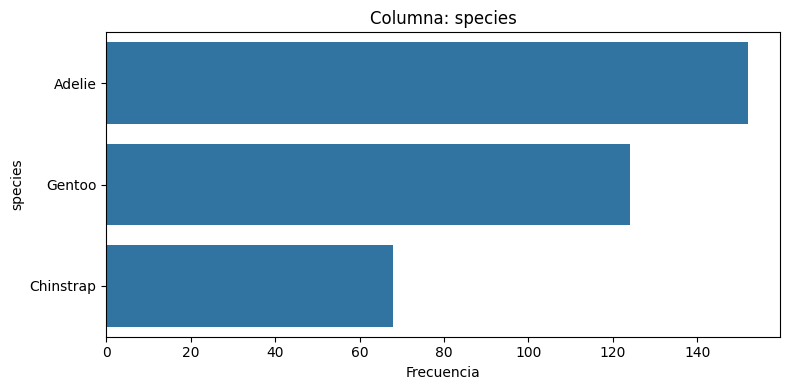

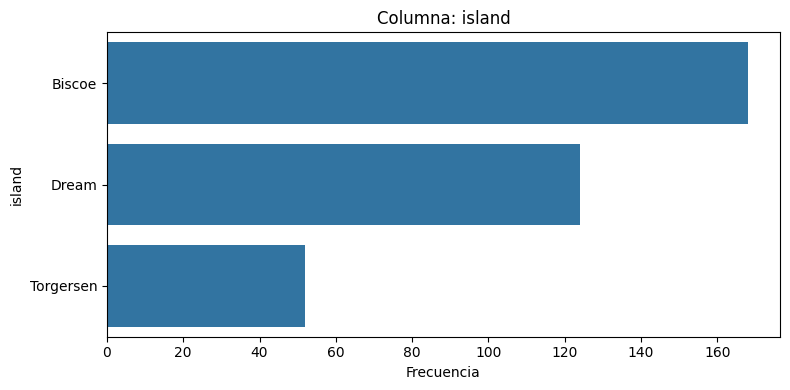

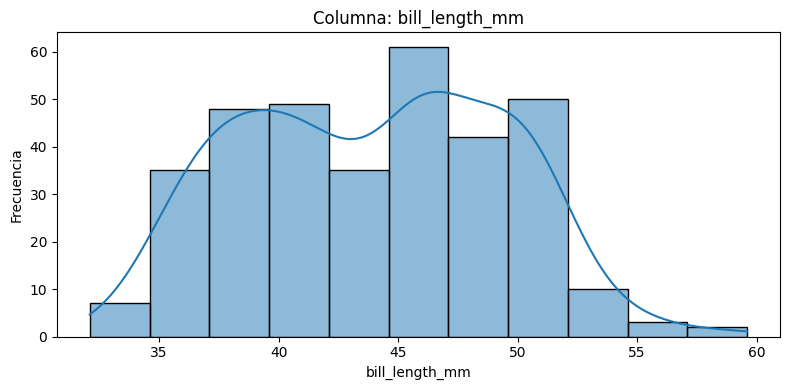

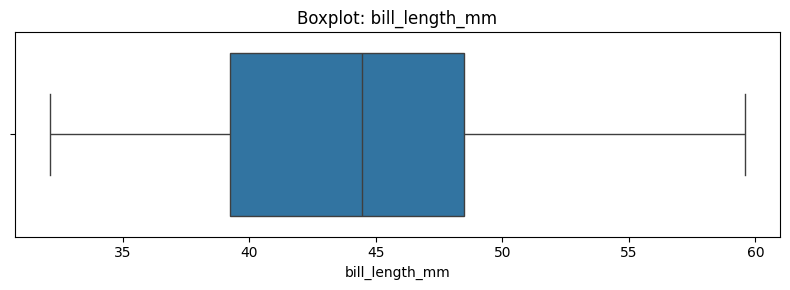

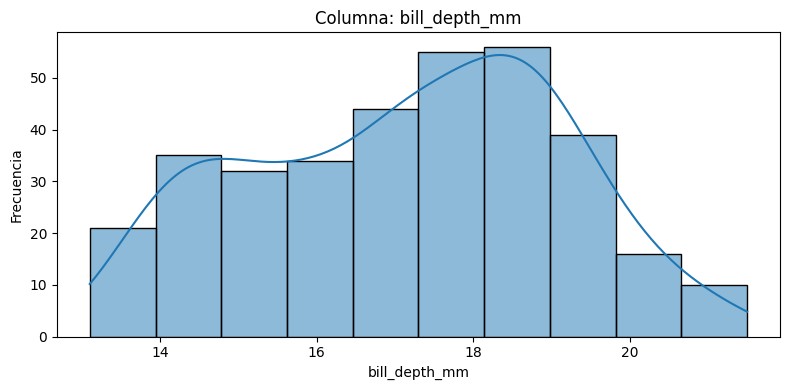

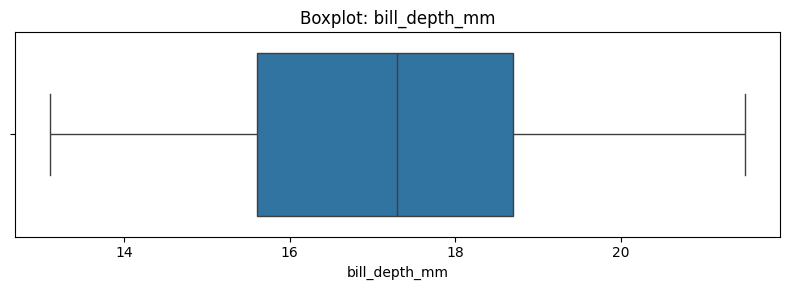

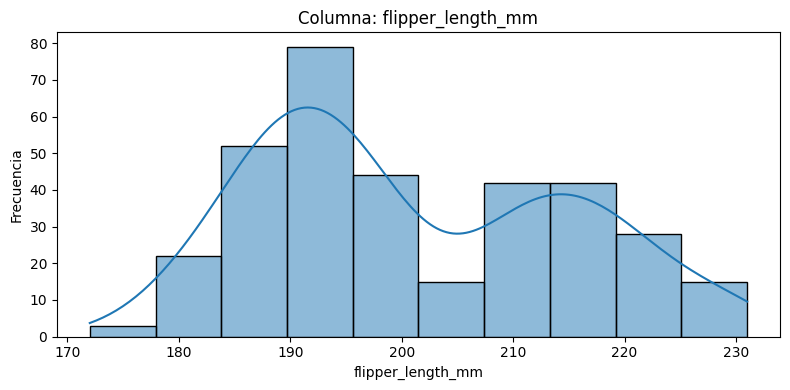

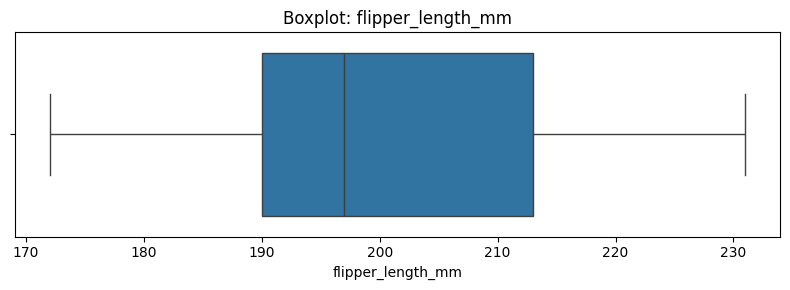

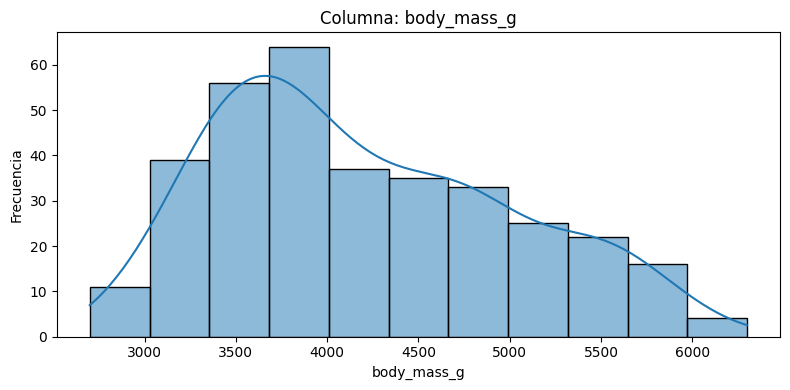

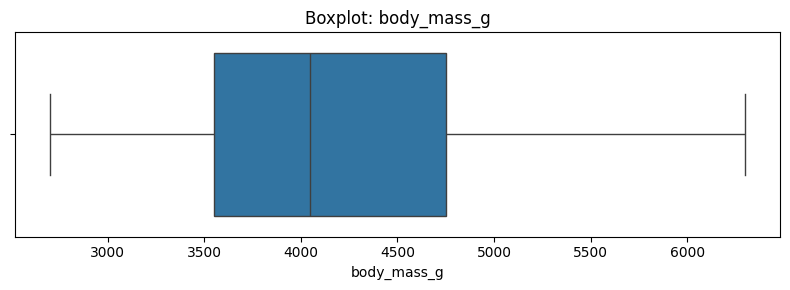

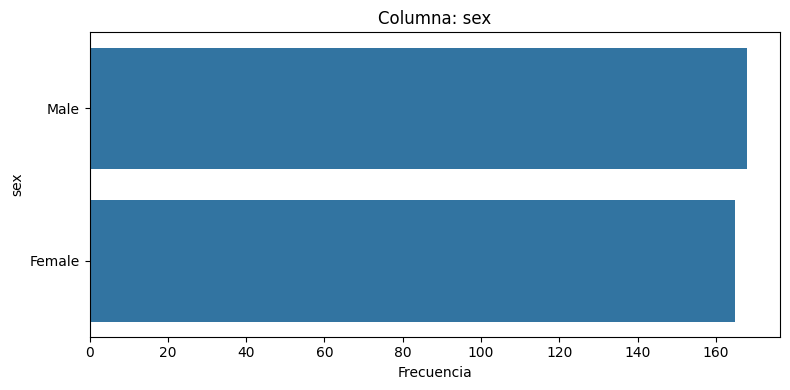

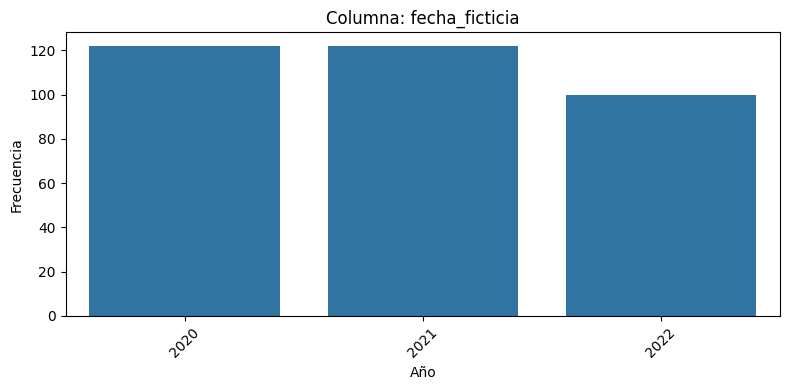

In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.api.types import is_numeric_dtype, is_datetime64_any_dtype

def explorar_columnas(df, max_categorias=10):
    for col in df.columns:
        serie = df[col].dropna()

        plt.figure(figsize=(8, 4))
        plt.title(f"Columna: {col}")

        if is_numeric_dtype(serie):
            sns.histplot(serie, kde=True)
            plt.xlabel(col)
            plt.ylabel("Frecuencia")
            plt.tight_layout()
            plt.show()

            plt.figure(figsize=(8, 3))
            sns.boxplot(x=serie)
            plt.title(f"Boxplot: {col}")
            plt.tight_layout()
            plt.show()

        elif is_datetime64_any_dtype(serie):
            anos = serie.dt.year.value_counts().sort_index()
            sns.barplot(x=anos.index.astype(str), y=anos.values)
            plt.xticks(rotation=45)
            plt.xlabel("Año")
            plt.ylabel("Frecuencia")
            plt.tight_layout()
            plt.show()

        else:
            top_valores = serie.astype(str).value_counts().head(max_categorias)
            sns.barplot(x=top_valores.values, y=top_valores.index)
            plt.xlabel("Frecuencia")
            plt.ylabel(col)
            plt.tight_layout()
            plt.show()

# Ejemplo con dataset de Seaborn

df_ejemplo = sns.load_dataset("penguins")

# Agregamos fecha ficticia para el ejemplo. Frecuencia cada tres días desde fecha inicial.

df_ejemplo["fecha_ficticia"] = pd.to_datetime(
    pd.date_range(start="2020-01-01", periods=len(df_ejemplo), freq="3D"))

explorar_columnas(df_ejemplo)


Comentarios generales:

- Exploramos cada columna automáticamente:
    - si es numérica, mostramos distribución y boxplot.
    - si es categórica, mostramos los valores más frecuentes.
    - si es fecha, mostramos los años más frecuentes.
- De esta forma obtenemos una visión rápida y sistemática del dataset.


Exercici 2: Optimització de rutes (problema aplicat)

Context:

L'empresa no disposa d'un control fiable del quilometratge dels desplaçaments dels seus treballadors. Abans d'implementar un sistema avançat, es vol fer una prova pilot amb treballadors ubicats a Espanya.

Per a aquesta prova:

- Es treballa amb una matriu de distàncies entre ciutats.
- Es vol una solució simple, raonable i explicable.
- No es busca la ruta òptima, sinó una aproximació coherent.

Carrega l'arxiu matriu_distancies.xlsx a pandas de manera que les files i columnes siguin les ciutats i s'eliminin "Las Palmas de Gran Canaria" i "Palma".

Desenvolupa una funció que:

- Rebi: una ciutat d'origen i una ciutat de destinació.
- Retorni: l'ordre de les ciutats visitades (ruta) i la distància total recorreguda.

La ruta s'ha de construir seguint una estratègia senzilla: anar sempre a la ciutat no visitada més propera fins a arribar a la destinació.

In [60]:
import pandas as pd

# Cargamos la matriz

matriz = pd.read_excel(
    "matriu_distancies.xlsx",
    index_col=0
)

# Eliminamos las ciudades excluidas

ciudades_excluidas = ["Las Palmas de Gran Canaria", "Palma"]
matriz = matriz.drop(index=ciudades_excluidas, errors="ignore")
matriz = matriz.drop(columns=ciudades_excluidas, errors="ignore")

# Nos aseguramos que filas y columnas coincidan

matriz.index = matriz.index.astype(str)
matriz.columns = matriz.columns.astype(str)

In [58]:
def calcular_ruta(origen, destino, matriz_distancias):
    if origen not in matriz_distancias.index:
        raise ValueError(f"Origen no encontrado: {origen}")
    if destino not in matriz_distancias.index:
        raise ValueError(f"Destino no encontrado: {destino}")

    ruta = [origen]
    visitadas = {origen}
    distancia_total = 0
    ciudad_actual = origen

    while ciudad_actual != destino:
        no_visitadas = [c for c in matriz_distancias.index if c not in visitadas]

        if not no_visitadas:
            raise ValueError("No hay ninguna ciudad disponible para continuar la ruta.")

        distancias_posibles = matriz_distancias.loc[ciudad_actual, no_visitadas].dropna()

        if distancias_posibles.empty:
            raise ValueError(f"No hay conexiones disponibles desde {ciudad_actual}.")

        siguiente_ciudad = distancias_posibles.idxmin()
        distancia = distancias_posibles.min()

        ruta.append(siguiente_ciudad)
        visitadas.add(siguiente_ciudad)
        distancia_total += distancia
        ciudad_actual = siguiente_ciudad

        if ciudad_actual == destino:
            break

    return ruta, distancia_total


In [62]:
# Prueba 1

ruta, distancia = calcular_ruta("Vigo", "Barcelona", matriz)
print("Ruta:", " -> ".join(ruta))
print("Distancia total:", distancia)

Ruta: Vigo -> Gijón -> Bilbao -> Valladolid -> Zaragoza -> Valencia -> Alicante -> Murcia -> Córdoba -> Sevilla -> Málaga -> Hospitalet de Llobregat -> Barcelona
Distancia total: 2873.0


In [63]:
# Prueba 2

ruta, distancia = calcular_ruta("Madrid", "Barcelona", matriz)
print("Ruta:", " -> ".join(ruta))
print("Distancia total:", distancia)

ValueError: Origen no encontrado: Madrid

Comentarios generales:

- Cargamos la matriz de distancias y eliminamos las dos ciudades indicadas.
- Creamos una ruta  que busca la ciudad no visitada más cercana hasta que llegamos a destino.
- Devolvemos la ruta completa y la distancia total.